# FGDN Project Visualization Notebook

This notebook creates report-ready figures for the corrected FGDN project.

Current project state:
- Dataset: ABIDE preprocessed ROI time-series
- Atlases completed: AAL and HarvardOxford
- Connectivity: tangent
- Models: unweighted FGDN and weighted FGDN
- Figures saved under `outputs/figures/`

Figures generated:
1. Dataset summary
2. Accuracy/AUC result comparisons
3. Corrected pipeline diagram
4. ASD/HC mean FC heatmaps
5. ASD/HC template adjacency heatmaps
6. Circular graph-template visualizations
7. Brain-style ROI score/connectome plots when atlas coordinates are available

Important note: the original paper's Figure 5 uses MODL_128 region-ablation/fine-tuning. Since MODL_128 is not integrated in this project, this notebook creates similar report-style AAL/HarvardOxford visualizations using template differences.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Change this path if your project is elsewhere.
PROJECT_ROOT = Path(r"D:/FGDN_Project")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figure output folder:", FIG_DIR)

Project root: D:\FGDN_Project
Figure output folder: D:\FGDN_Project\outputs\figures


## 1. Current Final Results

In [2]:
results = pd.DataFrame([
    {"variant": "Unweighted", "atlas": "AAL", "folds": 5, "accuracy_mean": 0.657150, "accuracy_std": 0.052083, "auc_mean": 0.733335, "auc_std": 0.039354},
    {"variant": "Unweighted", "atlas": "AAL", "folds": 10, "accuracy_mean": 0.662858, "accuracy_std": 0.058932, "auc_mean": 0.747608, "auc_std": 0.066337},
    {"variant": "Unweighted", "atlas": "HarvardOxford", "folds": 5, "accuracy_mean": 0.671970, "accuracy_std": 0.016687, "auc_mean": 0.732362, "auc_std": 0.011817},
    {"variant": "Unweighted", "atlas": "HarvardOxford", "folds": 10, "accuracy_mean": 0.692352, "accuracy_std": 0.050286, "auc_mean": 0.739556, "auc_std": 0.038684},
    {"variant": "Weighted", "atlas": "AAL", "folds": 5, "accuracy_mean": 0.664750, "accuracy_std": 0.042253, "auc_mean": 0.746564, "auc_std": 0.031682},
    {"variant": "Weighted", "atlas": "AAL", "folds": 10, "accuracy_mean": 0.670335, "accuracy_std": 0.038649, "auc_mean": 0.760592, "auc_std": 0.061851},
    {"variant": "Weighted", "atlas": "HarvardOxford", "folds": 5, "accuracy_mean": 0.656112, "accuracy_std": 0.030566, "auc_mean": 0.722158, "auc_std": 0.023552},
    {"variant": "Weighted", "atlas": "HarvardOxford", "folds": 10, "accuracy_mean": 0.677605, "accuracy_std": 0.034057, "auc_mean": 0.744680, "auc_std": 0.032152},
])
results["setting"] = results["atlas"] + " " + results["folds"].astype(str) + "-fold " + results["variant"]
results

,variant,atlas,folds,accuracy_mean,accuracy_std,auc_mean,auc_std,setting
0,Unweighted,AAL,5,0.657150,0.052083,0.733335,0.039354,AAL 5-fold Unweighted
1,Unweighted,AAL,10,0.662858,0.058932,0.747608,0.066337,AAL 10-fold Unweighted
2,Unweighted,HarvardOxford,5,0.671970,0.016687,0.732362,0.011817,HarvardOxford 5-fold Unweighted
3,Unweighted,HarvardOxford,10,0.692352,0.050286,0.739556,0.038684,HarvardOxford 10-fold Unweighted
4,Weighted,AAL,5,0.664750,0.042253,0.746564,0.031682,AAL 5-fold Weighted
5,Weighted,AAL,10,0.670335,0.038649,0.760592,0.061851,AAL 10-fold Weighted
6,Weighted,HarvardOxford,5,0.656112,0.030566,0.722158,0.023552,HarvardOxford 5-fold Weighted
7,Weighted,HarvardOxford,10,0.677605,0.034057,0.744680,0.032152,HarvardOxford 10-fold Weighted


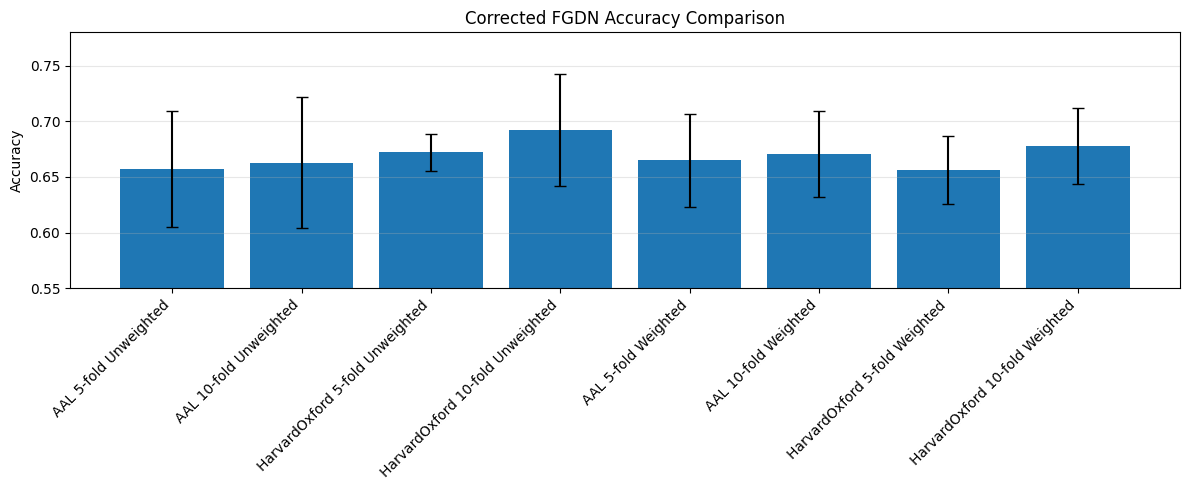

Saved: D:\FGDN_Project\outputs\figures\fgdn_accuracy_comparison.png


In [3]:
# Accuracy comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results))
ax.bar(x, results["accuracy_mean"], yerr=results["accuracy_std"], capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(results["setting"], rotation=45, ha="right")
ax.set_ylabel("Accuracy")
ax.set_title("Corrected FGDN Accuracy Comparison")
ax.set_ylim(0.55, 0.78)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = FIG_DIR / "fgdn_accuracy_comparison.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out)

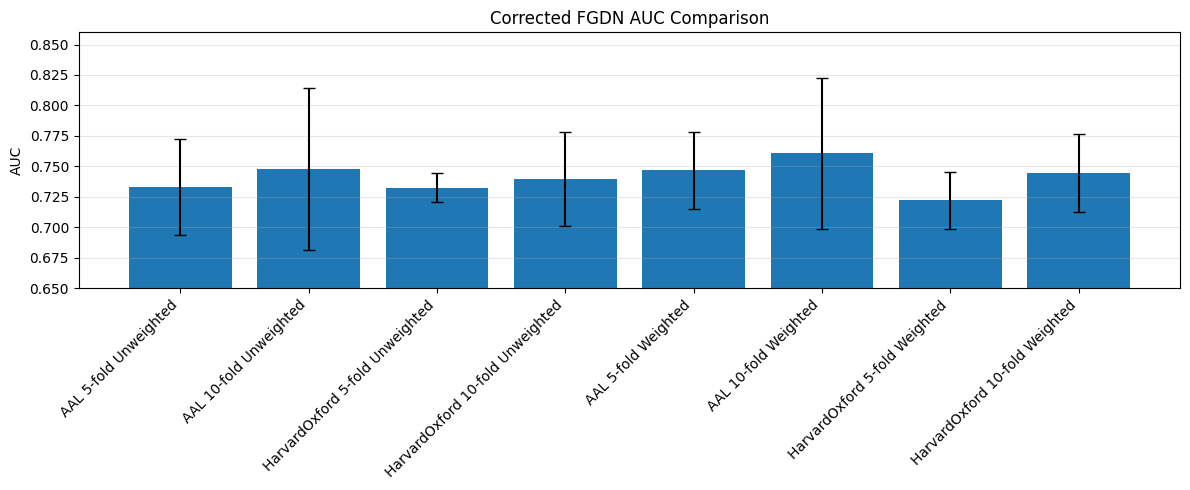

Saved: D:\FGDN_Project\outputs\figures\fgdn_auc_comparison.png


In [4]:
# AUC comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results))
ax.bar(x, results["auc_mean"], yerr=results["auc_std"], capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(results["setting"], rotation=45, ha="right")
ax.set_ylabel("AUC")
ax.set_title("Corrected FGDN AUC Comparison")
ax.set_ylim(0.65, 0.86)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = FIG_DIR / "fgdn_auc_comparison.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out)

## 2. Dataset Summary Figure

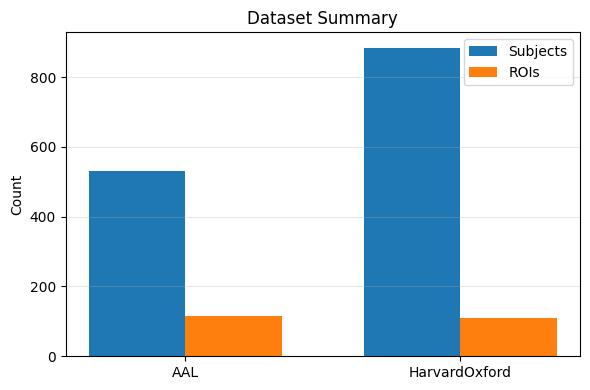

Saved: D:\FGDN_Project\outputs\figures\dataset_summary.png


In [5]:
dataset_summary = pd.DataFrame([
    {"atlas": "AAL", "subjects": 531, "rois": 116},
    {"atlas": "HarvardOxford", "subjects": 884, "rois": 111},
])

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(dataset_summary))
width = 0.35
ax.bar(x - width/2, dataset_summary["subjects"], width, label="Subjects")
ax.bar(x + width/2, dataset_summary["rois"], width, label="ROIs")
ax.set_xticks(x)
ax.set_xticklabels(dataset_summary["atlas"])
ax.set_title("Dataset Summary")
ax.set_ylabel("Count")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = FIG_DIR / "dataset_summary.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out)

## 3. Corrected Pipeline Diagram

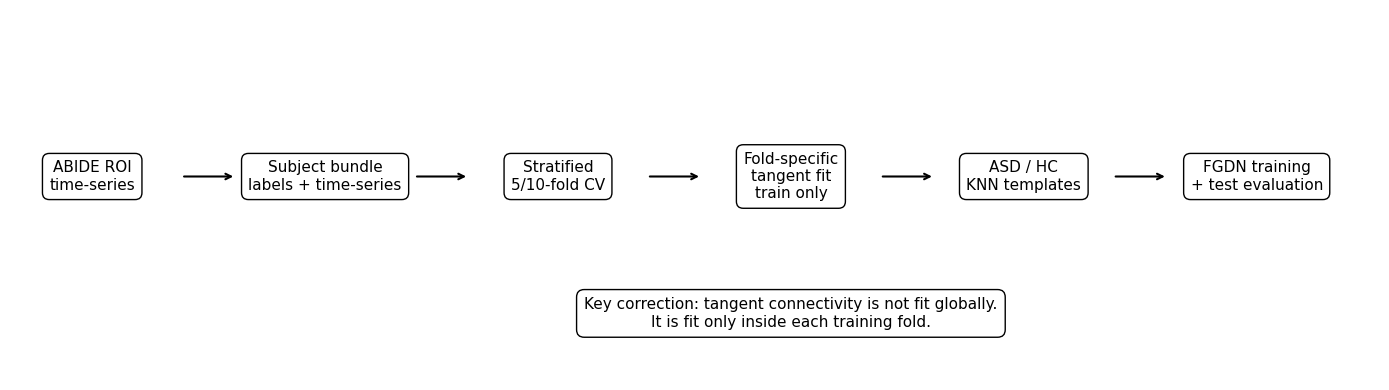

Saved: D:\FGDN_Project\outputs\figures\corrected_pipeline_diagram.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.axis("off")
boxes = [
    ("ABIDE ROI\ntime-series", 0.06, 0.55),
    ("Subject bundle\nlabels + time-series", 0.23, 0.55),
    ("Stratified\n5/10-fold CV", 0.40, 0.55),
    ("Fold-specific\ntangent fit\ntrain only", 0.57, 0.55),
    ("ASD / HC\nKNN templates", 0.74, 0.55),
    ("FGDN training\n+ test evaluation", 0.91, 0.55),
]
for text, x0, y0 in boxes:
    ax.text(x0, y0, text, ha="center", va="center", fontsize=11, bbox=dict(boxstyle="round,pad=0.45", edgecolor="black", facecolor="white"))
for i in range(len(boxes) - 1):
    x1 = boxes[i][1] + 0.065
    x2 = boxes[i + 1][1] - 0.065
    ax.annotate("", xy=(x2, 0.55), xytext=(x1, 0.55), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.text(0.57, 0.18, "Key correction: tangent connectivity is not fit globally.\nIt is fit only inside each training fold.", ha="center", va="center", fontsize=11, bbox=dict(boxstyle="round,pad=0.5", edgecolor="black", facecolor="white"))
plt.tight_layout()
out = FIG_DIR / "corrected_pipeline_diagram.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out)

## 4. Helper Functions for Loading Templates

In [7]:
def load_template(project_root, atlas="AAL", kind="tangent", num_folds=10, fold=1):
    template_dir = project_root / "data" / "interim" / "graph_templates" / atlas / kind / f"{num_folds}_fold" / f"fold_{fold}"
    paths = {
        "asd_mean_fc": template_dir / "ASD_mean_fc.npy",
        "hc_mean_fc": template_dir / "HC_mean_fc.npy",
        "asd_adj": template_dir / "ASD_adjacency.npy",
        "hc_adj": template_dir / "HC_adjacency.npy",
        "asd_edge_index": template_dir / "ASD_edge_index.npy",
        "hc_edge_index": template_dir / "HC_edge_index.npy",
    }
    missing = [str(p) for p in paths.values() if not p.exists()]
    if missing:
        raise FileNotFoundError("Missing template files:\n" + "\n".join(missing))
    return {k: np.load(v, allow_pickle=True) for k, v in paths.items()}

def plot_matrix(mat, title, out_name, cmap="viridis"):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat, aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("ROI")
    ax.set_ylabel("ROI")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    out = FIG_DIR / out_name
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out)

def top_symmetric_edges(matrix, top_n=50):
    mat = np.array(matrix, dtype=float).copy()
    np.fill_diagonal(mat, 0.0)
    iu = np.triu_indices_from(mat, k=1)
    values = np.abs(mat[iu])
    order = np.argsort(values)[::-1][:top_n]
    out = np.zeros_like(mat, dtype=float)
    rows = iu[0][order]
    cols = iu[1][order]
    out[rows, cols] = mat[rows, cols]
    out[cols, rows] = mat[cols, rows]
    return out

## 5. ASD/HC Mean FC and Template Heatmaps

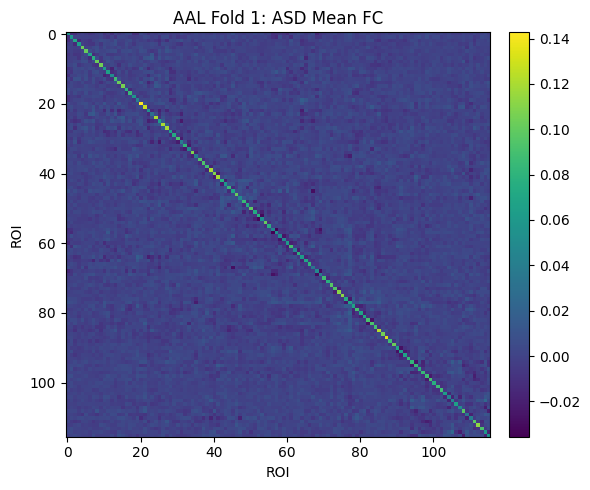

Saved: D:\FGDN_Project\outputs\figures\AAL_fold1_ASD_mean_fc.png


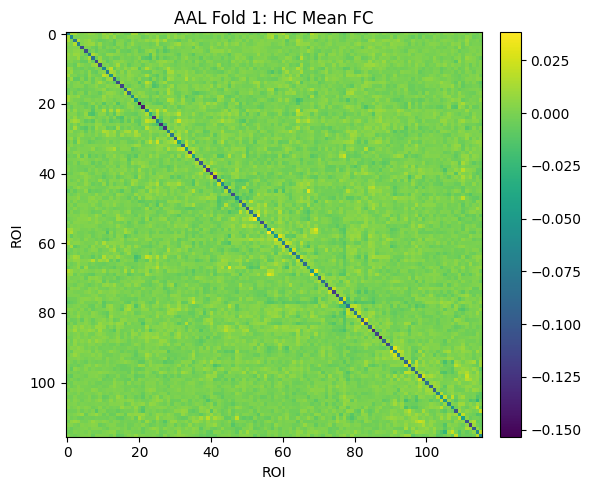

Saved: D:\FGDN_Project\outputs\figures\AAL_fold1_HC_mean_fc.png


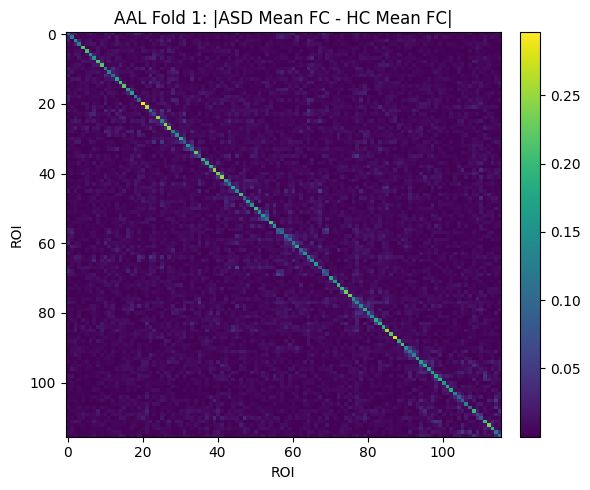

Saved: D:\FGDN_Project\outputs\figures\AAL_fold1_ASD_HC_fc_difference.png


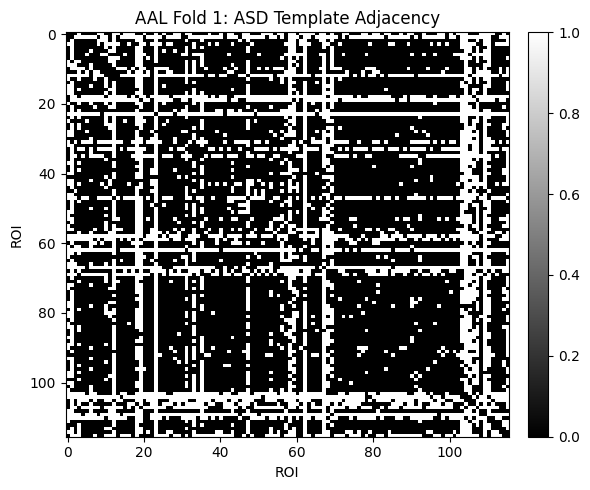

Saved: D:\FGDN_Project\outputs\figures\AAL_fold1_ASD_template_adjacency.png


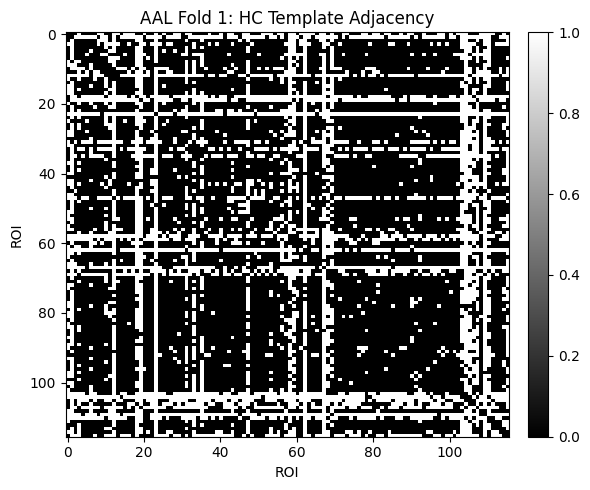

Saved: D:\FGDN_Project\outputs\figures\AAL_fold1_HC_template_adjacency.png


In [8]:
ATLAS = "AAL"
NUM_FOLDS = 10
FOLD = 1
KIND = "tangent"

try:
    tpl = load_template(PROJECT_ROOT, atlas=ATLAS, kind=KIND, num_folds=NUM_FOLDS, fold=FOLD)
    plot_matrix(tpl["asd_mean_fc"], f"{ATLAS} Fold {FOLD}: ASD Mean FC", f"{ATLAS}_fold{FOLD}_ASD_mean_fc.png")
    plot_matrix(tpl["hc_mean_fc"], f"{ATLAS} Fold {FOLD}: HC Mean FC", f"{ATLAS}_fold{FOLD}_HC_mean_fc.png")
    plot_matrix(np.abs(tpl["asd_mean_fc"] - tpl["hc_mean_fc"]), f"{ATLAS} Fold {FOLD}: |ASD Mean FC - HC Mean FC|", f"{ATLAS}_fold{FOLD}_ASD_HC_fc_difference.png")
    plot_matrix(tpl["asd_adj"], f"{ATLAS} Fold {FOLD}: ASD Template Adjacency", f"{ATLAS}_fold{FOLD}_ASD_template_adjacency.png", cmap="gray")
    plot_matrix(tpl["hc_adj"], f"{ATLAS} Fold {FOLD}: HC Template Adjacency", f"{ATLAS}_fold{FOLD}_HC_template_adjacency.png", cmap="gray")
except Exception as e:
    print("Could not plot template heatmaps:", e)

## 6. Circular Template Graph Visualization

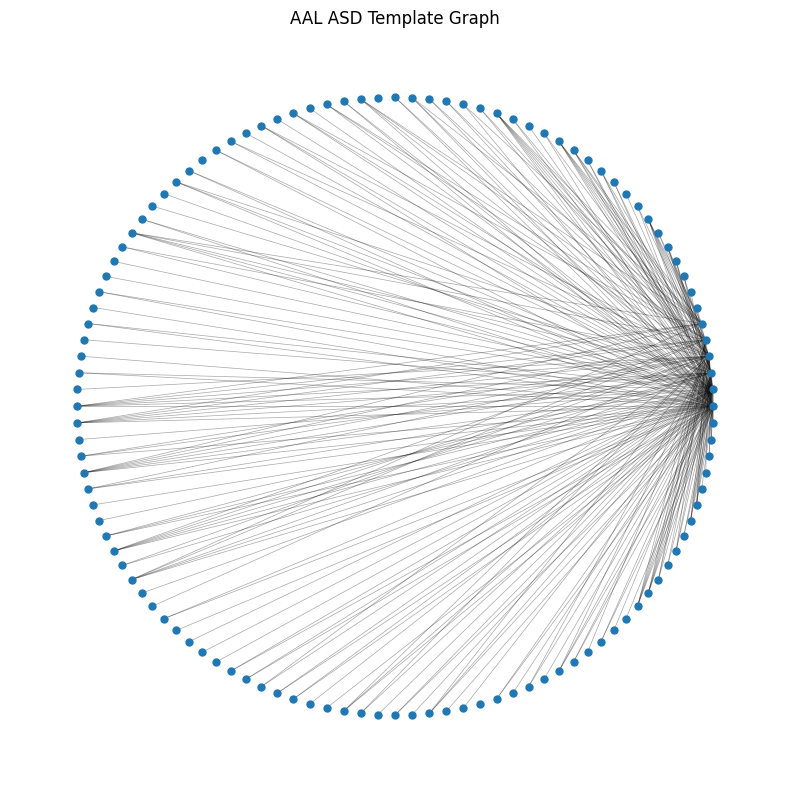

Saved: D:\FGDN_Project\outputs\figures\AAL_ASD_template_circular_graph.png


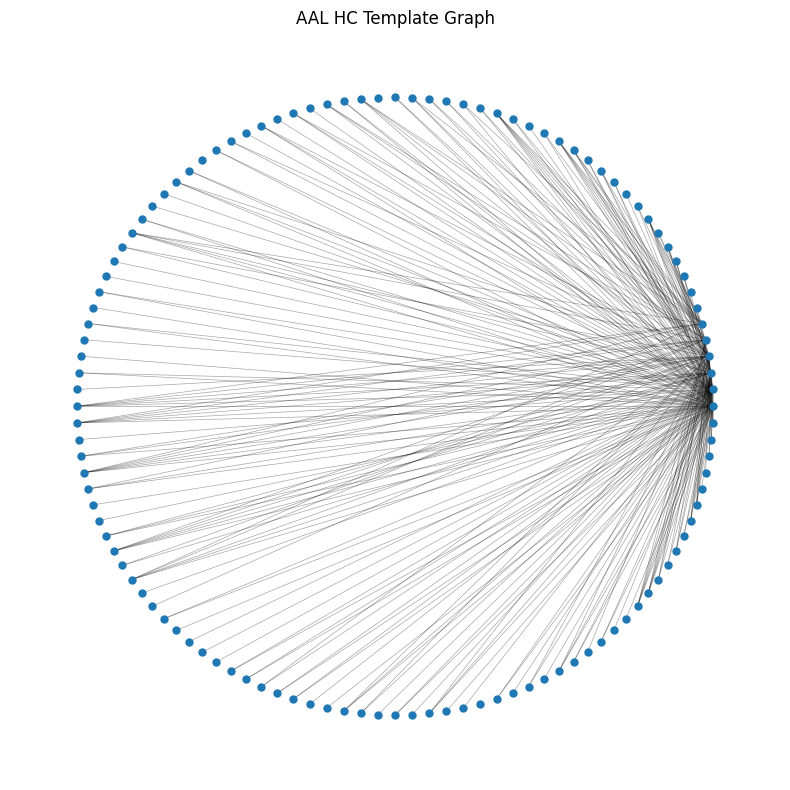

Saved: D:\FGDN_Project\outputs\figures\AAL_HC_template_circular_graph.png


In [9]:
try:
    import networkx as nx

    def plot_circular_template_graph(adjacency, title, out_name, max_edges=250):
        n = adjacency.shape[0]
        rows, cols = np.where(np.triu(adjacency, k=1) > 0)
        edges = list(zip(rows.tolist(), cols.tolist()))[:max_edges]
        G = nx.Graph()
        G.add_nodes_from(range(n))
        G.add_edges_from(edges)
        pos = nx.circular_layout(G)
        fig, ax = plt.subplots(figsize=(8, 8))
        nx.draw_networkx_nodes(G, pos, node_size=25, ax=ax)
        nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.35, ax=ax)
        ax.set_title(title)
        ax.axis("off")
        plt.tight_layout()
        out = FIG_DIR / out_name
        plt.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out)

    plot_circular_template_graph(tpl["asd_adj"], f"{ATLAS} ASD Template Graph", f"{ATLAS}_ASD_template_circular_graph.png")
    plot_circular_template_graph(tpl["hc_adj"], f"{ATLAS} HC Template Graph", f"{ATLAS}_HC_template_circular_graph.png")
except Exception as e:
    print("Could not create circular graph visualization:", e)

## 7. Brain-Style ROI Importance Visualization

The paper's exact brain plot uses MODL_128 region-ablation. Here we use an approximate ROI score based on ASD/HC template difference:

`score_i = mean_j |ASD_mean_FC[i, j] - HC_mean_FC[i, j]|`

In [10]:
roi_scores = np.mean(np.abs(tpl["asd_mean_fc"] - tpl["hc_mean_fc"]), axis=1)
top_idx = np.argsort(roi_scores)[::-1][:10]
pd.DataFrame({"roi_index": top_idx, "roi_score": roi_scores[top_idx]})

,roi_index,roi_score
0,77,0.011923
1,25,0.010718
2,85,0.010666
3,64,0.010490
4,83,0.010232
5,27,0.009848
6,91,0.009741
7,31,0.009693
8,78,0.009687
9,35,0.009654


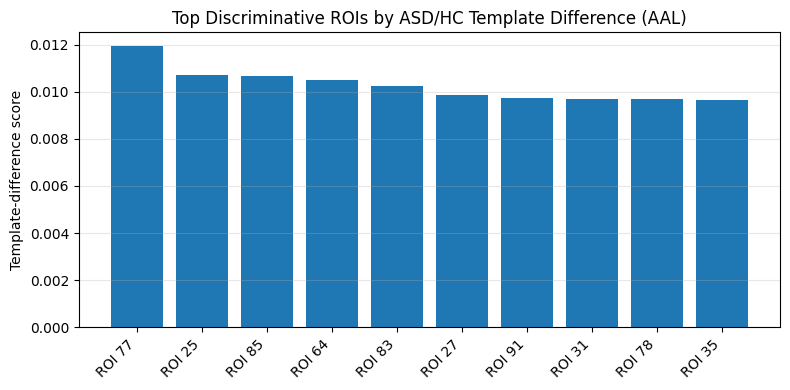

Saved: D:\FGDN_Project\outputs\figures\AAL_top_roi_scores.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(top_idx))
ax.bar(x, roi_scores[top_idx])
ax.set_xticks(x)
ax.set_xticklabels([f"ROI {i}" for i in top_idx], rotation=45, ha="right")
ax.set_ylabel("Template-difference score")
ax.set_title(f"Top Discriminative ROIs by ASD/HC Template Difference ({ATLAS})")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
out = FIG_DIR / f"{ATLAS}_top_roi_scores.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", out)

## 8. Anatomical Brain Plot Using Nilearn

This attempts to plot AAL ROI scores on a glass brain. Install if needed: `pip install nilearn`. If coordinate count does not match the project ROI count, the cell safely skips.

In [14]:
# Temporary SSL bypass only for downloading the Nilearn AAL atlas.
# Use this if Windows/Python certificate verification blocks the download.

import ssl
import requests
import urllib3

ssl._create_default_https_context = ssl._create_unverified_context
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

_old_request = requests.Session.request

def _unsafe_request(self, method, url, **kwargs):
    kwargs["verify"] = False
    return _old_request(self, method, url, **kwargs)

requests.Session.request = _unsafe_request

print("Temporary SSL verification bypass enabled for this notebook session.")

Temporary SSL verification bypass enabled for this notebook session.


In [15]:
try:
    from nilearn import datasets, plotting
    from nilearn.plotting import find_parcellation_cut_coords

    if ATLAS == "AAL":
        aal = datasets.fetch_atlas_aal()
        coords = find_parcellation_cut_coords(labels_img=aal.maps)
        print("AAL coordinates shape:", coords.shape)
        print("Project ROI count:", len(roi_scores))

        if coords.shape[0] != len(roi_scores):
            print("Coordinate count does not match project ROI count. Skipping anatomical plot.")
        else:
            display = plotting.plot_markers(roi_scores, coords, node_size=80, display_mode="ortho", title=f"{ATLAS}: Template-Difference ROI Scores", colorbar=True)
            out = FIG_DIR / f"{ATLAS}_roi_scores_glass_brain.png"
            display.savefig(str(out), dpi=300)
            plotting.show()
            print("Saved:", out)

            diff_mat = np.abs(tpl["asd_mean_fc"] - tpl["hc_mean_fc"])
            top_edges = top_symmetric_edges(diff_mat, top_n=60)
            display = plotting.plot_connectome(top_edges, coords, edge_threshold=None, node_size=20, display_mode="ortho", title=f"{ATLAS}: Top ASD/HC Template-Difference Edges")
            out = FIG_DIR / f"{ATLAS}_top_difference_edges_connectome.png"
            display.savefig(str(out), dpi=300)
            plotting.show()
            print("Saved:", out)
    else:
        print("Automatic anatomical plot is configured for AAL. For HarvardOxford, provide a coordinate CSV or atlas image matching your 111 ROI order.")
except Exception as e:
    print("Could not create Nilearn brain plot:", e)

[fetch_atlas_aal] Dataset created in C:\Users\Asus\nilearn_data\aal_3v2
[fetch_atlas_aal] Downloading data from https://www.gin.cnrs.fr/wp-content/uploads/AAL3v2_for_SPM12.tar.gz ...
[fetch_atlas_aal] Error while fetching file AAL3v2_for_SPM12.tar.gz; dataset fetching aborted.
Could not create Nilearn brain plot: HTTPSConnectionPool(host='www.gin.cnrs.fr', port=443): Max retries exceeded with url: /wp-content/uploads/AAL3v2_for_SPM12.tar.gz (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)')))


## 9. Optional Training Curves From Logs

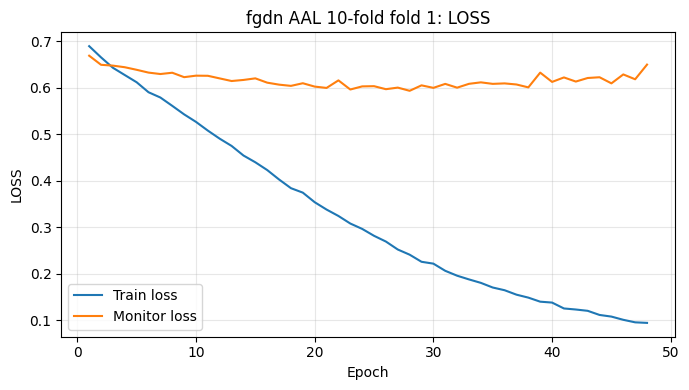

Saved: D:\FGDN_Project\outputs\figures\fgdn_AAL_10fold_fold1_loss_curve.png


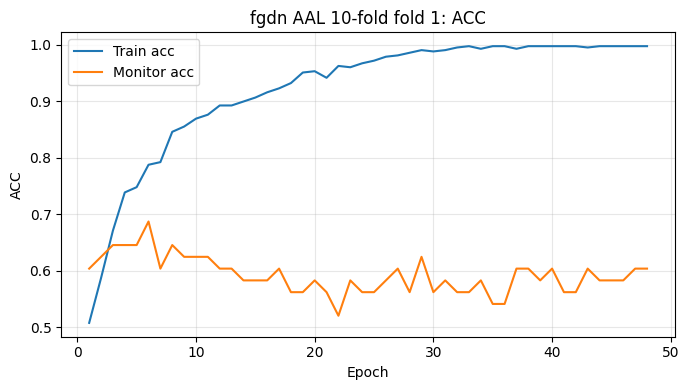

Saved: D:\FGDN_Project\outputs\figures\fgdn_AAL_10fold_fold1_acc_curve.png


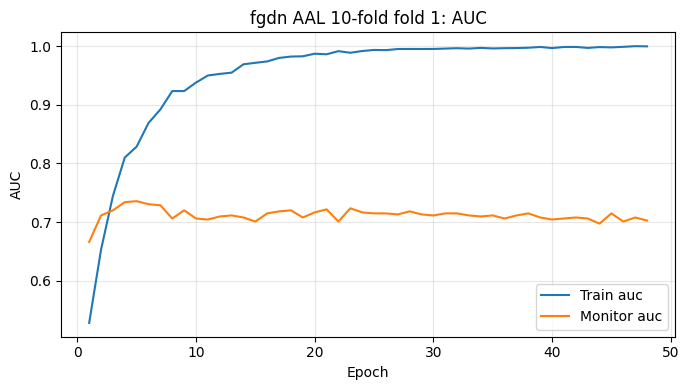

Saved: D:\FGDN_Project\outputs\figures\fgdn_AAL_10fold_fold1_auc_curve.png


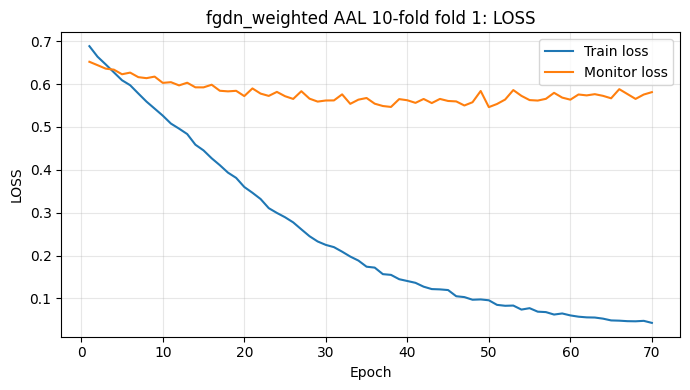

Saved: D:\FGDN_Project\outputs\figures\fgdn_weighted_AAL_10fold_fold1_loss_curve.png


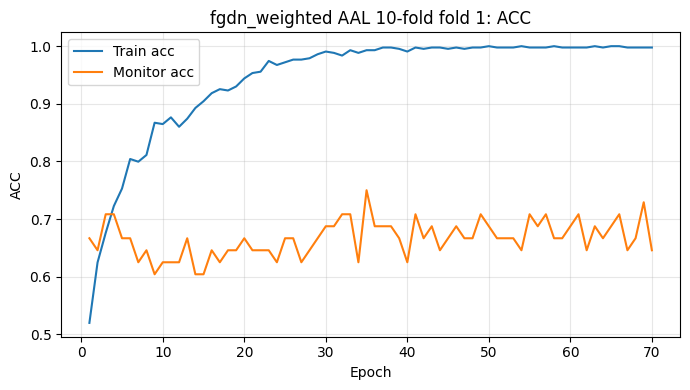

Saved: D:\FGDN_Project\outputs\figures\fgdn_weighted_AAL_10fold_fold1_acc_curve.png


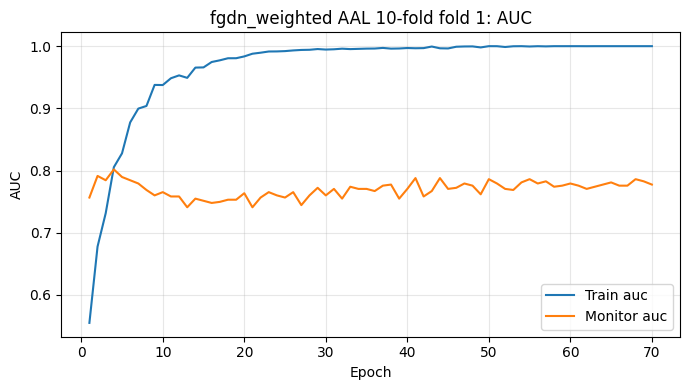

Saved: D:\FGDN_Project\outputs\figures\fgdn_weighted_AAL_10fold_fold1_auc_curve.png


In [13]:
def plot_training_history(project_root, variant="fgdn", atlas="AAL", num_folds=10, fold=1):
    log_path = project_root / "data" / "processed" / "logs" / variant / atlas / f"{num_folds}_fold" / f"fold_{fold}" / "training_history.csv"
    if not log_path.exists():
        print("Missing training history:", log_path)
        return
    hist = pd.read_csv(log_path)
    for metric in ["loss", "acc", "auc"]:
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(hist["epoch"], hist[f"train_{metric}"], label=f"Train {metric}")
        ax.plot(hist["epoch"], hist[f"monitor_{metric}"], label=f"Monitor {metric}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric.upper())
        ax.set_title(f"{variant} {atlas} {num_folds}-fold fold {fold}: {metric.upper()}")
        ax.grid(alpha=0.3)
        ax.legend()
        plt.tight_layout()
        out = FIG_DIR / f"{variant}_{atlas}_{num_folds}fold_fold{fold}_{metric}_curve.png"
        plt.savefig(out, dpi=300, bbox_inches="tight")
        plt.show()
        print("Saved:", out)

plot_training_history(PROJECT_ROOT, variant="fgdn", atlas="AAL", num_folds=10, fold=1)
plot_training_history(PROJECT_ROOT, variant="fgdn_weighted", atlas="AAL", num_folds=10, fold=1)

## 10. Exact Paper-Style Discriminative Brain Figure: What Is Still Needed

The original paper's Figure 5 is not only a plotting step. It requires an additional MODL_128 region-ablation experiment:

1. Train FGDN on MODL tangent features.
2. For each MODL region `R_i`, keep only that region's features.
3. Clamp the other 127 region features to zero.
4. Fine-tune or evaluate the trained model.
5. Use averaged validation ACC/AUC as the region's discriminative score.
6. Plot top regions as brain maps.

To reproduce that exactly, this project still needs MODL_128 integration, MODL spatial maps/coordinates aligned with ROI ordering, a region-ablation script, and plotting code for MODL components.

For the stopped current project, use the template-difference and result figures generated above.

## 11. Recommended Figures for the Report

Use these generated files:

```text
outputs/figures/dataset_summary.png
outputs/figures/corrected_pipeline_diagram.png
outputs/figures/fgdn_accuracy_comparison.png
outputs/figures/fgdn_auc_comparison.png
outputs/figures/AAL_fold1_ASD_mean_fc.png
outputs/figures/AAL_fold1_HC_mean_fc.png
outputs/figures/AAL_fold1_ASD_HC_fc_difference.png
outputs/figures/AAL_fold1_ASD_template_adjacency.png
outputs/figures/AAL_fold1_HC_template_adjacency.png
outputs/figures/AAL_top_roi_scores.png
outputs/figures/AAL_roi_scores_glass_brain.png
outputs/figures/AAL_top_difference_edges_connectome.png
```